# Interprétabilité du modèle final
### Scoring de risque de crédit — Séance 9

On repart du modèle retenu (régression logistique pondérée, C=100 trouvé en S8). L'objectif ici : comprendre et expliquer *comment* le modèle prend ses décisions, pas seulement *combien* il se trompe.

## Étape 0 — Reconstituer le modèle final (S4 à S8)

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/Loan_default.csv")

mois_emploi_maximum_plausible = (df["Age"] - 16) * 12
df["AgeEmploymentIncoherent"] = (df["MonthsEmployed"] > mois_emploi_maximum_plausible).astype(int)

for colonne in ["HasMortgage", "HasDependents", "HasCoSigner"]:
    df[colonne] = df[colonne].map({"Yes": 1, "No": 0})
df["Education_encoded"] = df["Education"].map({"High School": 0, "Bachelor's": 1, "Master's": 2, "PhD": 3})
df = pd.get_dummies(df, columns=["EmploymentType", "MaritalStatus", "LoanPurpose"],
                     prefix=["EmploymentType", "MaritalStatus", "LoanPurpose"])
colonnes_one_hot = [col for col in df.columns if col.startswith(("EmploymentType_", "MaritalStatus_", "LoanPurpose_"))]
for colonne in colonnes_one_hot:
    df[colonne] = df[colonne].astype(int)
df["LoanToIncomeRatio"] = df["LoanAmount"] / df["Income"]
df = df.drop(columns=["LoanID", "Education"])

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X = df.drop(columns=["Default"])
y = df["Default"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Meilleur C trouve en S8
modele_final = LogisticRegression(C=100, random_state=42, max_iter=1000, class_weight="balanced")
modele_final.fit(X_train_scaled, y_train)

print("Modele final reconstitue.")

Modele final reconstitue.


---
# 1. Extraire et lire les coefficients

`modele_final.coef_` donne un coefficient par variable, dans le même ordre que les colonnes de `X`.

In [2]:
coefficients = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": modele_final.coef_[0]
})

# odds ratio = exp(coefficient) : plus intuitif a lire
coefficients["Odds_ratio"] = np.exp(coefficients["Coefficient"])

# On trie par magnitude (valeur absolue du coefficient), independamment du signe
coefficients["Magnitude"] = coefficients["Coefficient"].abs()
coefficients = coefficients.sort_values("Magnitude", ascending=False).drop(columns="Magnitude")

coefficients.head(15).round(3)

,Variable,Coefficient,Odds_ratio
0,Age,-0.598,0.550
26,LoanToIncomeRatio,0.473,1.605
6,InterestRate,0.468,1.596
4,MonthsEmployed,-0.338,0.713
11,HasCoSigner,-0.133,0.876
10,HasDependents,-0.129,0.879
3,CreditScore,-0.126,0.882
5,NumCreditLines,0.106,1.111
14,EmploymentType_Full-time,-0.104,0.901
13,Education_encoded,-0.103,0.902


**Comment lire un coefficient :**
- **Signe positif** → la variable augmente le risque de défaut prédit.
- **Signe négatif** → la variable diminue le risque de défaut prédit.
- **Odds ratio > 1** → chaque hausse d'un écart-type de la variable multiplie les chances de défaut par cette valeur. **Odds ratio < 1** → les chances de défaut sont divisées d'autant.

## 2. Visualiser les variables les plus influentes

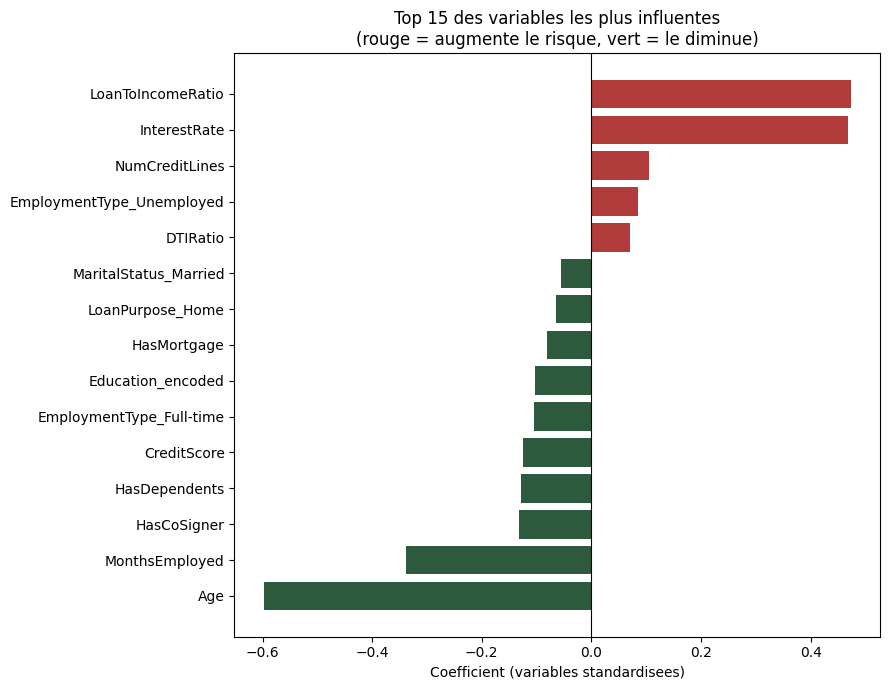

In [3]:
import matplotlib.pyplot as plt

top15 = coefficients.head(15).sort_values("Coefficient")
couleurs = ["#B23B3B" if c > 0 else "#2D5A3D" for c in top15["Coefficient"]]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top15["Variable"], top15["Coefficient"], color=couleurs)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (variables standardisees)")
ax.set_title("Top 15 des variables les plus influentes\n(rouge = augmente le risque, vert = le diminue)")
plt.tight_layout()
plt.savefig("../reports/figures/coefficients_S9.png", dpi=150)
plt.show()

## 3. Vérifier la cohérence avec les séances précédentes

Un bon signe de fiabilité : est-ce que les variables les plus influentes ici correspondent à celles identifiées comme statistiquement significatives en S3 (tests t et χ²), et à l'importance calculée par le Random Forest en S7 ?

In [4]:
print("Top 5 des variables les plus influentes (regression logistique, S9) :")
print(coefficients.head(5)[["Variable", "Coefficient", "Odds_ratio"]].to_string(index=False))

print()
print("Pour rappel (S3) : les variables les plus correlees a Default etaient")
print("Age (-0.17), InterestRate (+0.13), Income (-0.10), MonthsEmployed (-0.10), LoanAmount (+0.09)")
print()
print("Pour rappel (S7) : le Random Forest classait Age, InterestRate et LoanToIncomeRatio")
print("comme les 3 variables les plus importantes")

Top 5 des variables les plus influentes (regression logistique, S9) :
         Variable  Coefficient  Odds_ratio
              Age    -0.597623    0.550118
LoanToIncomeRatio     0.473154    1.605049
     InterestRate     0.467501    1.596001
   MonthsEmployed    -0.337718    0.713396
      HasCoSigner    -0.132523    0.875883

Pour rappel (S3) : les variables les plus correlees a Default etaient
Age (-0.17), InterestRate (+0.13), Income (-0.10), MonthsEmployed (-0.10), LoanAmount (+0.09)

Pour rappel (S7) : le Random Forest classait Age, InterestRate et LoanToIncomeRatio
comme les 3 variables les plus importantes


**Constat attendu :** les mêmes variables (`Age`, `InterestRate`, `Income`, `LoanToIncomeRatio`...) reviennent en tête dans les trois analyses (corrélations S3, importance Random Forest S7, coefficients de régression logistique S9), malgré des méthodes complètement différentes. C'est un signal de robustesse important : le signal détecté n'est pas un artefact d'une méthode particulière.

## 4. Limite à documenter honnêtement

Les variables issues du One-Hot Encoding (`EmploymentType_*`, `MaritalStatus_*`, `LoanPurpose_*`) sont des 0/1, mais elles ont été standardisées comme les autres en S6 (StandardScaler appliqué à toute la matrice). Leurs coefficients restent interprétables en signe (augmente/diminue le risque), mais leur magnitude est moins directement comparable à une lecture "toutes choses égales par ailleurs" classique qu'on aurait avec des variables binaires non standardisées. Une amélioration possible pour un travail plus poussé : exclure les variables binaires de la standardisation, ou recalculer un modèle dédié sans standardisation pour ces colonnes.

In [5]:
# Exemple concret : les variables categorielles dans le classement
variables_categorielles = coefficients[coefficients["Variable"].str.contains("EmploymentType|MaritalStatus|LoanPurpose")]
variables_categorielles.round(3)

,Variable,Coefficient,Odds_ratio
14,EmploymentType_Full-time,-0.104,0.901
17,EmploymentType_Unemployed,0.085,1.089
24,LoanPurpose_Home,-0.065,0.937
19,MaritalStatus_Married,-0.056,0.946
18,MaritalStatus_Divorced,0.040,1.040
22,LoanPurpose_Business,0.038,1.039
20,MaritalStatus_Single,0.016,1.017
15,EmploymentType_Part-time,0.014,1.014
21,LoanPurpose_Auto,0.010,1.011
23,LoanPurpose_Education,0.008,1.008


## 5. Exemple concret : lecture d'un profil individuel

In [6]:
# On prend un emprunteur au hasard dans le jeu de test, et on regarde
# comment le modele a construit sa prediction
index_exemple = 0
profil_exemple = X_test.iloc[[index_exemple]]
profil_scale = X_test_scaled[[index_exemple]]

probabilite_predite = modele_final.predict_proba(profil_scale)[0, 1]
realite = y_test.iloc[index_exemple]

print(f"Probabilite de defaut predite : {probabilite_predite:.3f}")
print(f"Realite observee (Default) : {realite}")
print()
print("Caracteristiques de cet emprunteur :")
print(profil_exemple[["Age", "Income", "InterestRate", "LoanToIncomeRatio", "CreditScore"]].to_string(index=False))

Probabilite de defaut predite : 0.198
Realite observee (Default) : 0

Caracteristiques de cet emprunteur :
 Age  Income  InterestRate  LoanToIncomeRatio  CreditScore
  54   20956          8.99              4.159          789


## 6. Sauvegarder le tableau des coefficients

In [7]:
coefficients.to_csv("../reports/coefficients_modele_final_S9.csv", index=False)
print("Coefficients sauvegardes.")

Coefficients sauvegardes.


## Résumé

- Coefficients extraits et convertis en odds ratios, pour une lecture directe de l'effet de chaque variable.
- Cohérence vérifiée entre trois méthodes différentes (corrélations S3, importance Random Forest S7, coefficients S9) : les mêmes variables ressortent en tête, ce qui renforce la confiance dans le signal détecté.
- Limite documentée honnêtement : la standardisation des variables binaires complique légèrement leur interprétation directe.

Prochaine étape (S10-S11) : rédaction du rapport final et préparation de la restitution.